# Mai24_CMLOPS_Accidents_Cdc_#2_Modeles

## 1- Analyse de corrélation de variables

In [4]:
# Import des bibliothèques nécessaires au projet
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
import time

# Ignorer les avertissements
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import pickle

In [3]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df = pd.read_csv('../src/data/data 2005a2021.csv', index_col=0)

In [6]:
# colonne non catégorielle
colonne_Non_cat=['num_acc', 'an_nais', "num_veh_x", 'annee', "num_veh_y", 'mois', 'jour', 'com', 'dep', 'hr', 'mn','nbv','lartpc','larrout']

# colonne catégorielle
cat_columns = [col for col in df.columns if col not in colonne_Non_cat]

In [7]:
import scipy.stats as stats

# calcul des corrélations pour les variables catégorielles uniquement
cat_corr = {}
for col in cat_columns:
    contingency_table = pd.crosstab(df['grav'], df[col])
    chi2, p, dof, ex = stats.chi2_contingency(contingency_table)
    cat_corr[col] = chi2

print("Chi2 avec 'grav':")
print(cat_corr)

Chi2 avec 'grav':
{'place': 55178.53061443179, 'catu': 55103.68293148403, 'grav': 8273517.999999998, 'sexe': 3970.6263657806367, 'trajet': 56750.688108034396, 'annee_x': 4151.290822989036, 'catv': 36263.34096499447, 'choc': 49133.43956007585, 'manv': 100058.04735826899, 'lum': 58104.928009028394, 'agg': 125691.1978552596, 'int': 32358.55530922233, 'atm': 7961.439699649734, 'col': 178112.6685110811, 'annee_y': 4151.290822989036, 'catr': 179027.2075456462, 'circ': 77884.89278231117, 'prof': 24222.208959768268, 'plan': 54918.24817794433, 'surf': 3230.4516509349914, 'situ': 39157.716797988105}


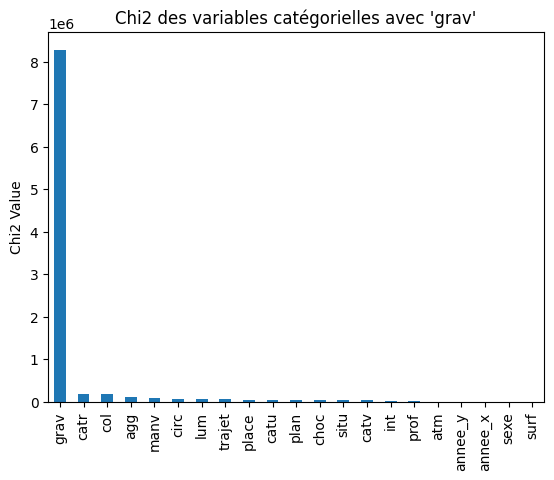

In [6]:
# bar plot pour les résultats du test du chi-carré
cat_corr_series = pd.Series(cat_corr).sort_values(ascending=False)
cat_corr_series.plot(kind='bar')
plt.title("Chi2 des variables catégorielles avec 'grav'")
plt.ylabel('Chi2 Value')
plt.show()

In [8]:
# le nombre de colonnes étant conséquent, nous cherchons à supprimer celles non nécessaires
# les variables atm, annee_y, annee_x, sexe et surf ne semblent pas corrélées avec grav - nous les supprimons donc
colonnes_a_supprimer = ['atm', 'annee_y', 'annee_x', 'sexe', 'surf', "num_veh_x", "num_veh_y"]
df = df.drop(columns=colonnes_a_supprimer)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4136759 entries, 200500000001 to 201900058840
Data columns (total 26 columns):
 #   Column   Dtype  
---  ------   -----  
 0   place    int64  
 1   catu     int64  
 2   grav     int64  
 3   trajet   float64
 4   an_nais  int64  
 5   catv     int64  
 6   choc     float64
 7   manv     float64
 8   mois     int64  
 9   jour     int64  
 10  lum      int64  
 11  agg      int64  
 12  int      int64  
 13  col      float64
 14  com      int64  
 15  dep      int64  
 16  hr       int64  
 17  mn       int64  
 18  catr     int64  
 19  circ     float64
 20  nbv      int64  
 21  prof     float64
 22  plan     float64
 23  lartpc   int64  
 24  larrout  int64  
 25  situ     float64
dtypes: float64(8), int64(18)
memory usage: 852.1 MB


## 2- Préparation du jeu de donnée - pré processing

In [10]:
# on sépare les variables cibles et les caractéristiques
X = df.drop(columns=['grav'])
y = df['grav']

In [11]:
# on divise les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# nous avons vu dans notre analyse de données que les classes 2 et 3 étaient sous représentées

# afin de régler ce déséquilibre de classe, nous allons faire un SMOTE et l'appliquer à nos données
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## 3- Entrainement de plusieurs modèles

In [14]:
# entrainement d un arbre de decision

model_tree_clf = DecisionTreeClassifier(random_state=42, max_depth=10)

start_time = time.time()
model_tree_clf.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

training_time = end_time - start_time
print(f"Temps d'entraînement du modèle : {training_time:.2f} secondes")

y_pred = model_tree_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

Temps d'entraînement du modèle : 206.62 secondes
Confusion Matrix:
[[522673  50345  81938]
 [  5990   7828   5185]
 [ 82787  30552  40054]]

Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.80      0.83    654956
           2       0.09      0.41      0.15     19003
           3       0.31      0.26      0.29    153393

    accuracy                           0.69    827352
   macro avg       0.42      0.49      0.42    827352
weighted avg       0.74      0.69      0.71    827352


Accuracy Score:
0.6896157862675137


In [15]:
# entrainement d un random forest

model_rf_clf = RandomForestClassifier(random_state=42)

start_time = time.time()
model_rf_clf.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

training_time = end_time - start_time
print(f"Temps d'entraînement du modèle : {training_time:.2f} secondes")

y_pred = model_rf_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

Temps d'entraînement du modèle : 8365.43 secondes
Confusion Matrix:
[[611035   2914  41007]
 [  9325   3140   6538]
 [ 98024   2005  53364]]

Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.93      0.89    654956
           2       0.39      0.17      0.23     19003
           3       0.53      0.35      0.42    153393

    accuracy                           0.81    827352
   macro avg       0.59      0.48      0.51    827352
weighted avg       0.78      0.81      0.79    827352


Accuracy Score:
0.8068379601427204


In [17]:
# nous souhaitons un modele predisant mieux les gravites eleves, 
# on sauvegarde donc le modele avec la meilleure  
import joblib
with open('model_rf_clf.pkl', 'wb') as file:
    joblib.dump(model_rf_clf, file)